|                |   |
:----------------|---|
| **Nombre**     |Santiago Escutia Ríos   |
| **Fecha**      | 23/3/2026  |
| **Expediente** |757839   |

Para solo 3 datos de X y de Y 

In [ ]:
Para solo 3 datos de X y de Y 

x máximo: 9.999999993138754
y máximo: 2846.971530284697


c:\Users\santiagoescutia\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Text(0.5, 1.0, 'Kernel: 31.6**2 * RBF(length_scale=0.656)')

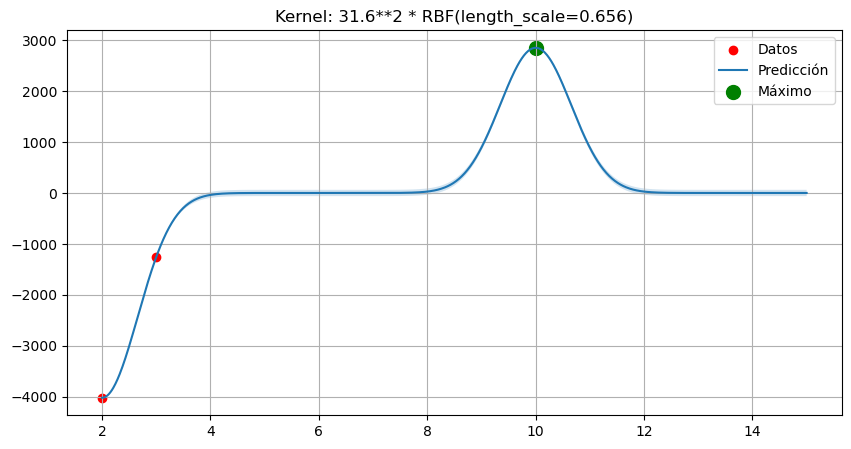

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize

# Datos
X = np.array([[10], [2], [3]])
y = np.array([2847, -4017, -1255])

# Modelo (kernel para curva)
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (0.1, 100.0))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)
gp.fit(X, y)

# Predicción para graficar
X_v = np.linspace(2, 15, 1000).reshape(-1, 1)
y_p, std = gp.predict(X_v, return_std=True)

# --------- BUSCAR MÁXIMO REAL (CONTINUO) ---------
# función negativa (porque minimize busca mínimo)
def f(x):
    return -gp.predict(np.array(x).reshape(-1,1))

# punto inicial
x0 = [10]

res = minimize(f, x0=x0, bounds=[(2,15)])
x_max = res.x[0]
y_max = gp.predict([[x_max]])[0]

print("x máximo:", x_max)
print("y máximo:", y_max)

# --------- GRÁFICA ---------
plt.figure(figsize=(10,5))
plt.scatter(X, y, color='red', label='Datos')
plt.plot(X_v, y_p, label='Predicción')
plt.fill_between(X_v.ravel(), y_p - 1.96*std, y_p + 1.96*std, alpha=0.2)

# marcar máximo
plt.scatter(x_max, y_max, color='green', s=100, label='Máximo')

plt.legend()
plt.grid()
plt.title(f"Kernel: {gp.kernel_}")

Aunque el valor máximo en los datos es 10, el modelo puede ubicar el máximo real ligeramente antes (como 9.996) porque construye una curva suave basada en probabilidades. Esto no es un error, sino que busca la mejor representación general y no solo copiar los puntos.